<a href="https://colab.research.google.com/github/ShahuPatil07/FISTA-Net-Medical-Image-Computing-CS-736/blob/main/mic_project_final_emt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Imports ready
LOAD_FROM_DRIVE = False
Train: 1920  Val: 480  Test1: 1200  Test2: 1200
✅ Helper functions defined
✅ EMTDataset class defined
Building sensitivity matrix A ...
  A shape : (64, 4096)
  Zero rows: 0  (must be 0)
Building Laplacian matrix L ...
  L shape : (4096, 4096)
Pre-computing warm-start operator M ...
  M shape : (4096, 64)
✅ A, L, M ready
Generating dataset (this takes ~15 min on Colab) ...


Generating (n=1920, objs=[1, 2, 4]):   0%|          | 0/1920 [00:00<?, ?it/s]

Generating (n=480, objs=[1, 2, 4]):   0%|          | 0/480 [00:00<?, ?it/s]

Generating (n=1200, objs=[1, 2, 4]):   0%|          | 0/1200 [00:00<?, ?it/s]

Generating (n=1200, objs=[3]):   0%|          | 0/1200 [00:00<?, ?it/s]

Mounted at /content/drive
  Saved train.pt
  Saved val.pt
  Saved test_set1.pt
  Saved test_set2.pt
✅ All saved to Drive — set LOAD_FROM_DRIVE=True for future runs

Dataset summary:
  Train :  1920 samples
  Val   :   480 samples
  Test1 :  1200 samples
  Test2 :  1200 samples

Tensor shapes:
  b    : (4, 64)       (paper: (N, 64))
  x0   : (4, 1, 64, 64)   (paper: (N, 1, 64, 64))
  x_gt : (4, 1, 64, 64)   (paper: (N, 1, 64, 64))


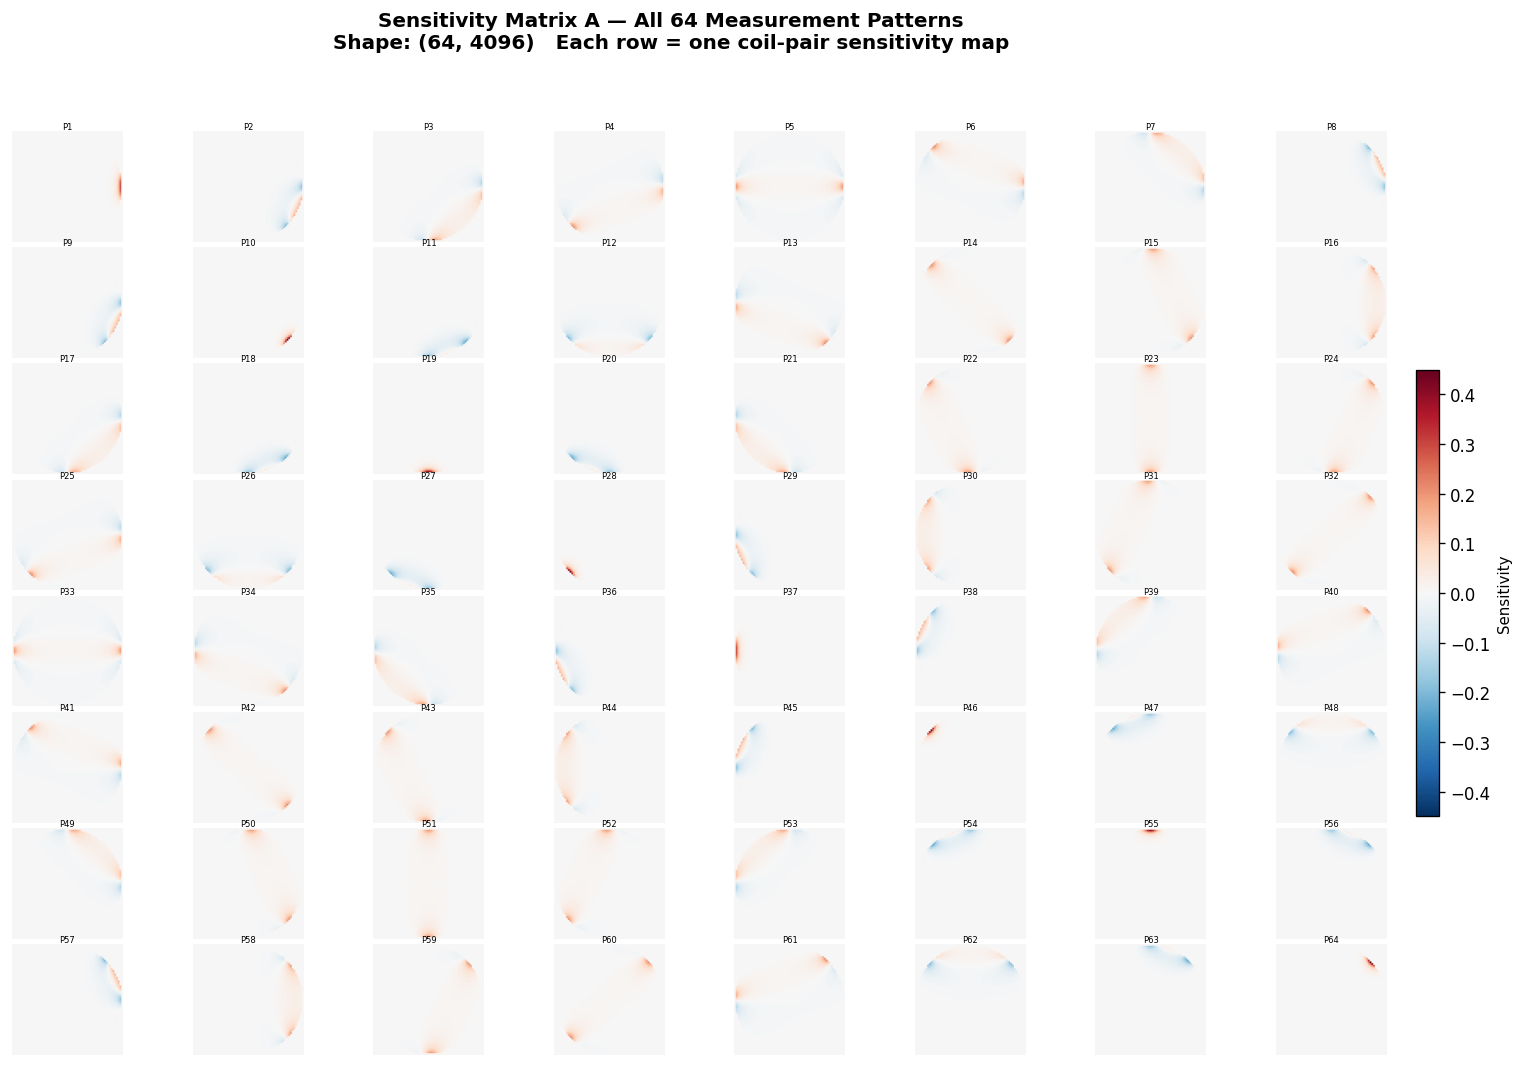

Zero rows: 0  (must be 0)


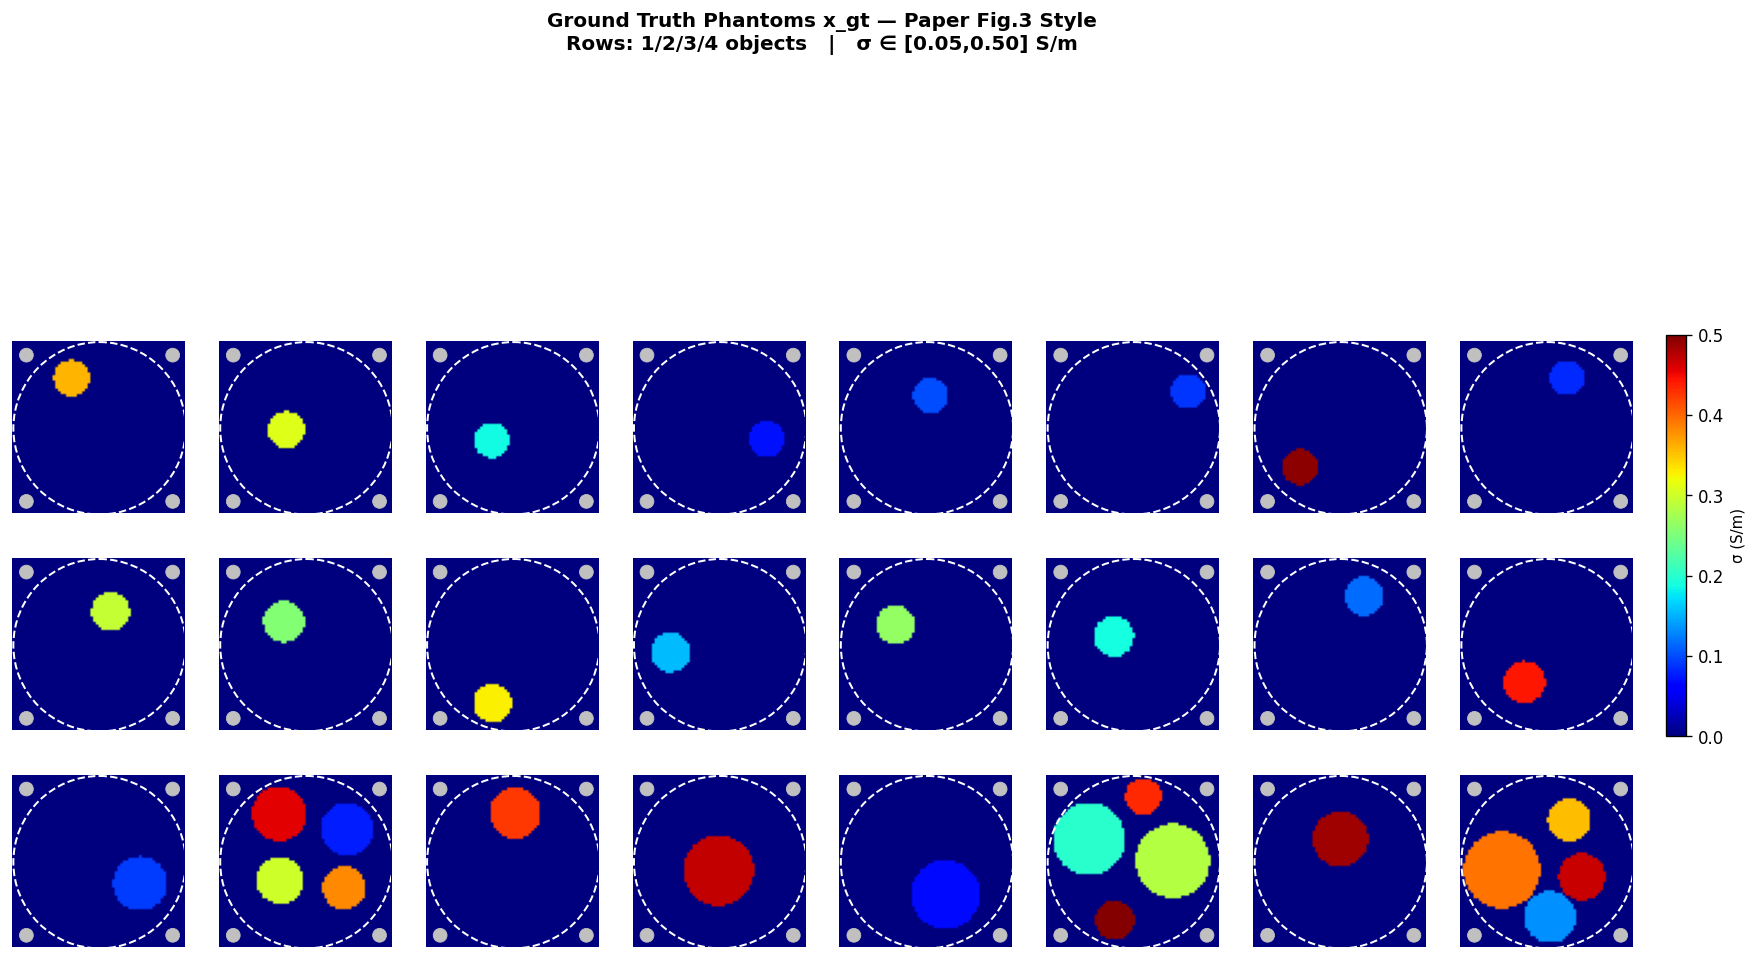

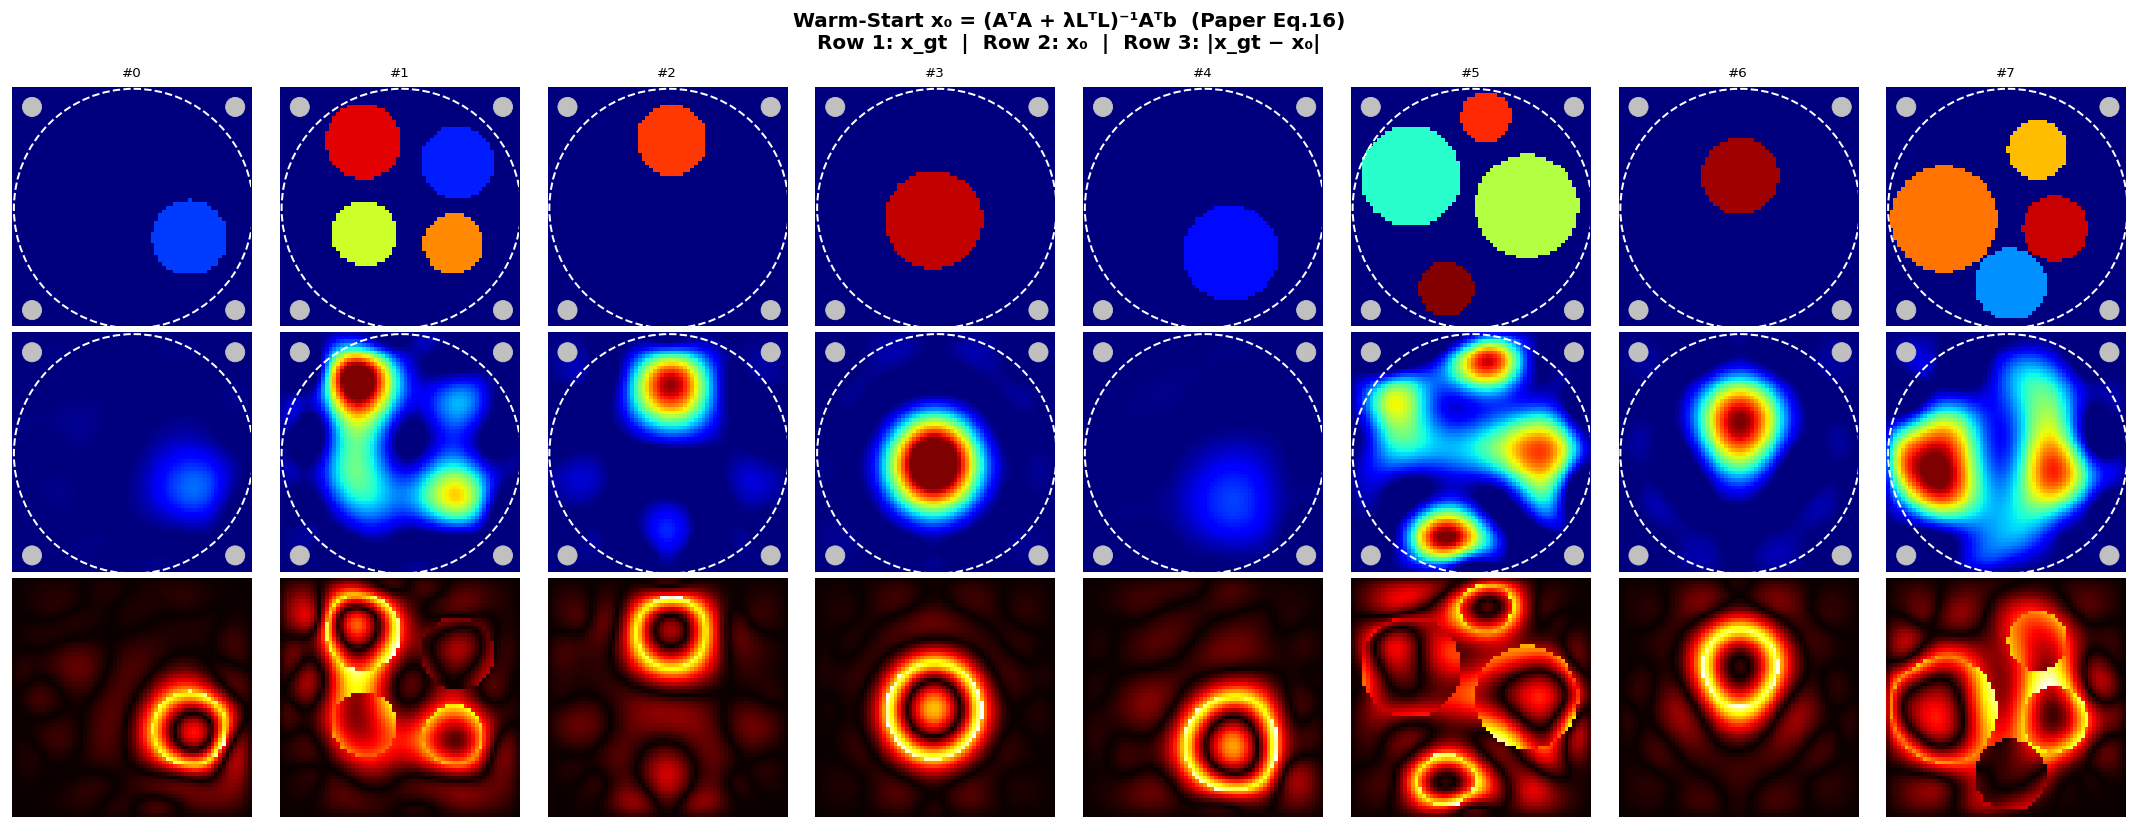

Warm-start RMSE: 0.0532 ± 0.0246 S/m


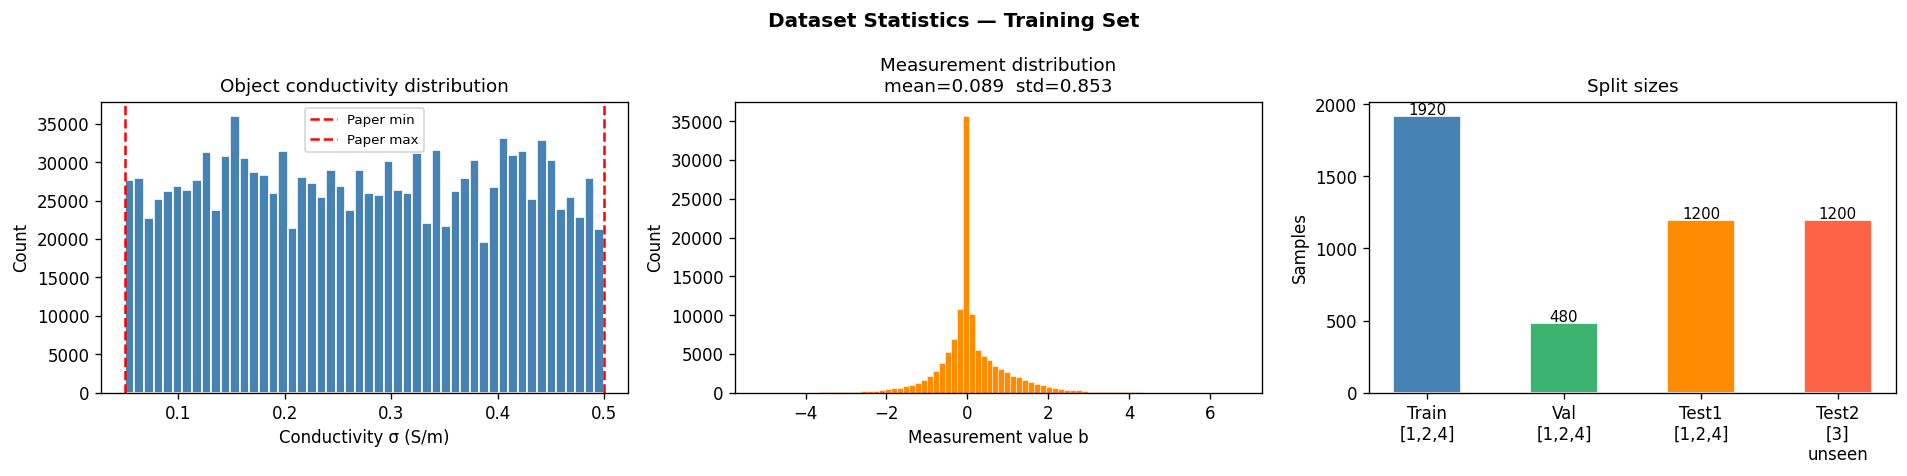

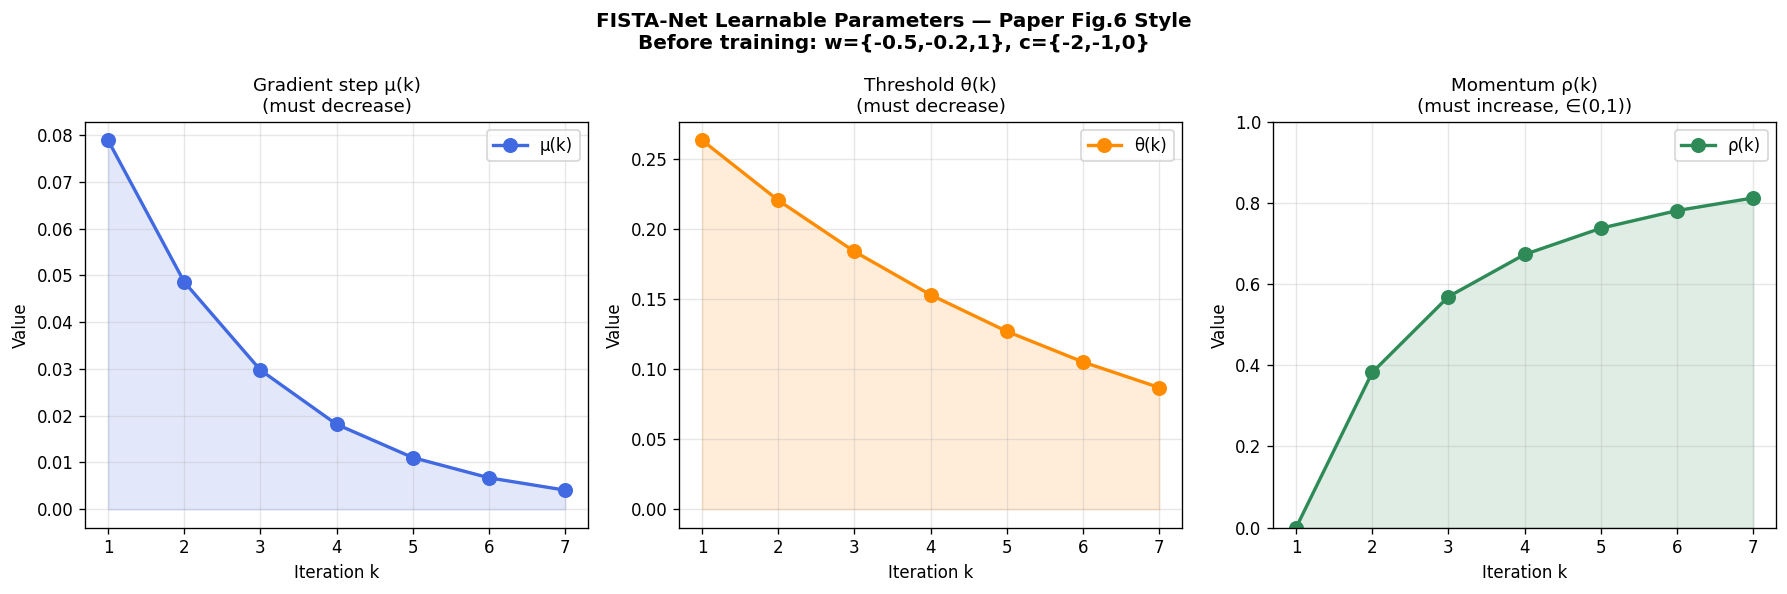


  k        μ(k)        θ(k)        ρ(k)
-------------------------------------
  1      0.0789      0.2633      0.0000
  2      0.0486      0.2204      0.3826
  3      0.0298      0.1839      0.5692
  4      0.0181      0.1530      0.6732
  5      0.0110      0.1269      0.7377
  6      0.0067      0.1051      0.7812
  7      0.0041      0.0868      0.8124


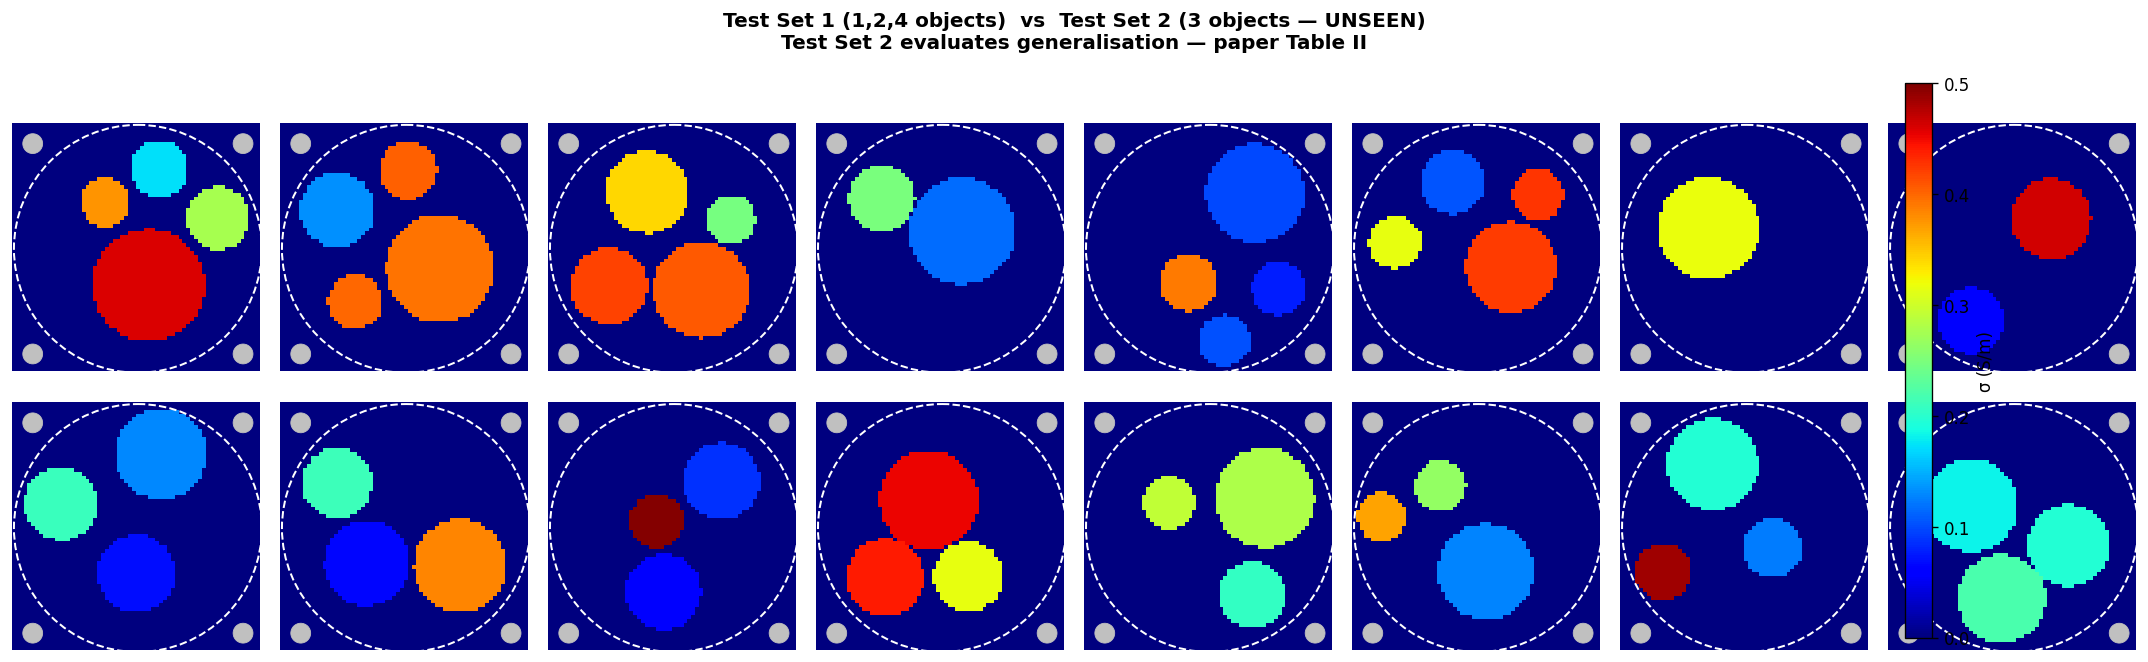


✅ Dataset generation + visualisation complete!
   Next step: build and train the FISTA-Net model

   DataLoaders ready to use:
     train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
     val_loader   = DataLoader(val_ds,   batch_size=64)
     test1_loader = DataLoader(test1_ds, batch_size=64)
     test2_loader = DataLoader(test2_ds, batch_size=64)


In [1]:
# ============================================================
# FISTA-Net EMT Dataset Generation + Visualisation
# For student project — scaled to ~10% of paper dataset
# ============================================================
# USAGE:
#   Step 1: Set LOAD_FROM_DRIVE = False, run everything once
#           (generates + saves dataset to Google Drive)
#   Step 2: Set LOAD_FROM_DRIVE = True for all future runs
#           (loads instantly from Drive)
# ============================================================

# ── Cell 1: Install dependencies ─────────────────────────────
# %%capture
# !pip install torch numpy matplotlib scipy tqdm -q


# ── Cell 2: Imports & style ──────────────────────────────────
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.size'       : 10,
    'axes.titlesize'  : 11,
    'axes.labelsize'  : 10,
    'figure.facecolor': 'white',
})

print("✅ Imports ready")


# ── Cell 3: CONFIG — change LOAD_FROM_DRIVE here ─────────────
# =============================================================
#  *** CHANGE THIS FLAG ***
#  False → generate dataset (run once, takes ~15 min on Colab)
#  True  → load from Drive (instant, use after first run)
# =============================================================
LOAD_FROM_DRIVE = False

# Dataset sizes  (paper: 24000 / 4800 / 12000 / 12000)
# Below is ~10% — enough for a student project
N_TRAIN  = 1920   # ← was 300 in original notebook
N_VAL    = 480    # ← new: 20% of train for validation
N_TEST1  = 1200   # ← was 100
N_TEST2  = 1200   # ← was 100

# Physics & image parameters (match paper exactly)
IMAGE_SIZE     = 64
N_MEASUREMENTS = 64
N_COILS        = 8
DOMAIN_RADIUS  = 0.15
SIGMA_MIN_OBJ  = 0.05
SIGMA_MAX_OBJ  = 0.50
SIGMA_BG       = 0.0
LAMBDA0        = 0.001   # warm-start regularisation (paper Eq.16)
BATCH_SIZE     = 64

SAVE_DIR = '/content/drive/MyDrive/FISTA_Net_EMT_Dataset_FIXED'

print(f"LOAD_FROM_DRIVE = {LOAD_FROM_DRIVE}")
print(f"Train: {N_TRAIN}  Val: {N_VAL}  Test1: {N_TEST1}  Test2: {N_TEST2}")


# ── Cell 4: Helper functions ──────────────────────────────────
def get_coil_positions(n=N_COILS, r=DOMAIN_RADIUS * 1.2):
    """8 coils placed evenly around the sensing boundary."""
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return np.column_stack([r * np.cos(angles), r * np.sin(angles)])


def build_A():
    """
    Build the 64×4096 sensitivity matrix A using analytical dipole fields.
    NOTE: paper uses COMSOL FEM — this is an approximation, which is
    acceptable for a student project. State this in your report.
    """
    coil_pos = get_coil_positions()
    lin = np.linspace(-DOMAIN_RADIUS, DOMAIN_RADIUS, IMAGE_SIZE)
    xx, yy = np.meshgrid(lin, lin)
    px, py = xx.ravel(), yy.ravel()
    mask = (px**2 + py**2) < DOMAIN_RADIUS**2
    Np = IMAGE_SIZE * IMAGE_SIZE

    def dipole_field(c, px, py):
        dx = px - c[0]; dy = py - c[1]
        r2 = dx**2 + dy**2 + 1e-12
        r3 = r2**1.5
        return 3*dx*dy / (r2*r3), (2*dy**2 - dx**2) / (r2*r3)

    A = np.zeros((N_MEASUREMENTS, Np), np.float32)
    idx = 0
    for tx in range(N_COILS):
        Bx, By = dipole_field(coil_pos[tx], px, py)
        for rx in range(N_COILS):
            if idx >= N_MEASUREMENTS:
                break
            Rx, Ry = dipole_field(coil_pos[rx], px, py)
            A[idx] = ((Bx*Rx + By*Ry) * mask).astype(np.float32)
            idx += 1

    # Normalise rows so no zero rows (verified below)
    norms = np.linalg.norm(A, axis=1, keepdims=True) + 1e-12
    return A / norms


def build_L():
    """Discrete Laplacian matrix for warm-start regularisation (Eq.16)."""
    N = IMAGE_SIZE**2
    L = np.zeros((N, N), np.float32)
    for i in range(IMAGE_SIZE):
        for j in range(IMAGE_SIZE):
            idx = i * IMAGE_SIZE + j
            L[idx, idx] = -4
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i+di, j+dj
                if 0 <= ni < IMAGE_SIZE and 0 <= nj < IMAGE_SIZE:
                    L[idx, ni*IMAGE_SIZE+nj] = 1
    return L


def gen_phantom(n_obj=1, rng=None):
    """
    Generate a random conductivity phantom with n_obj circular objects.
    Objects: random radius, location, conductivity in [0.05, 0.50] S/m.
    """
    if rng is None:
        rng = np.random.default_rng()
    lin = np.linspace(-DOMAIN_RADIUS, DOMAIN_RADIUS, IMAGE_SIZE)
    xx, yy = np.meshgrid(lin, lin)
    domain_mask = (xx**2 + yy**2) < DOMAIN_RADIUS**2
    phantom = np.zeros((IMAGE_SIZE, IMAGE_SIZE), np.float32)
    placed = []

    for _ in range(500 * n_obj):
        if len(placed) >= n_obj:
            break
        r  = rng.uniform(0.03, 0.07)
        mc = max(DOMAIN_RADIUS - r - 1e-4, DOMAIN_RADIUS * 0.3)
        cx = rng.uniform(-mc, mc)
        cy = rng.uniform(-mc, mc)
        if cx**2 + cy**2 > mc**2:
            continue
        if any(np.sqrt((cx-px)**2 + (cy-py)**2) < r + pr
               for px, py, pr in placed):
            continue
        sigma = rng.uniform(SIGMA_MIN_OBJ, SIGMA_MAX_OBJ)
        dist  = np.sqrt((xx - cx)**2 + (yy - cy)**2)
        phantom[(dist < r) & domain_mask] = sigma
        placed.append((cx, cy, r))

    return phantom


def simulate_measurement(phantom, A, snr_db=40.0, add_noise=True, rng=None):
    """
    Forward model: b = A·x + noise  (paper: SNR=40dB for train/val).
    Test sets use add_noise=False (clean measurements).
    """
    if rng is None:
        rng = np.random.default_rng()
    b = A @ phantom.ravel().astype(np.float32)
    if add_noise and np.isfinite(snr_db):
        signal_power = max(np.mean(b**2), 1e-8)
        noise_power  = signal_power / (10 ** (snr_db / 10))
        b += rng.normal(0, np.sqrt(noise_power), b.shape).astype(np.float32)
    return b.astype(np.float32)


def draw_coils(ax, coil_pos_m, scale, centre):
    """Draw 8 coils + sensing boundary on a phantom axes."""
    for cx, cy in coil_pos_m:
        ax.add_patch(plt.Circle(
            (centre + cx*scale, centre + cy*scale),
            IMAGE_SIZE*0.04, color='silver', zorder=5,
            linewidth=0.5, edgecolor='white'))
    ax.add_patch(plt.Circle(
        (centre, centre), DOMAIN_RADIUS*scale,
        color='white', fill=False, linewidth=1.2,
        linestyle='--', zorder=4))


print("✅ Helper functions defined")


# ── Cell 5: Dataset class ─────────────────────────────────────
class EMTDataset(torch.utils.data.Dataset):
    """
    Simple dataset holding (b, x0, x_gt) tensors.
    b    : measurement vector  [N_MEASUREMENTS]
    x0   : warm-start image    [1, IMAGE_SIZE, IMAGE_SIZE]
    x_gt : ground truth        [1, IMAGE_SIZE, IMAGE_SIZE]
    """
    def __init__(self, measurements, phantoms, x0s):
        self.b    = torch.from_numpy(measurements)                    # (N, 64)
        self.x0   = torch.from_numpy(x0s).unsqueeze(1)               # (N,1,64,64)
        self.x_gt = torch.from_numpy(phantoms).unsqueeze(1)          # (N,1,64,64)

    def __len__(self):
        return len(self.b)

    def __getitem__(self, i):
        return self.b[i], self.x0[i], self.x_gt[i]

    @classmethod
    def from_dict(cls, d):
        """Load from saved torch dict (used when LOAD_FROM_DRIVE=True)."""
        inst = object.__new__(cls)
        inst.b    = d['measurements']
        inst.x0   = d['x0']
        inst.x_gt = d['phantoms']
        return inst


print("✅ EMTDataset class defined")


# ── Cell 6: Build A and L (always needed) ─────────────────────
print("Building sensitivity matrix A ...")
A = build_A()
print(f"  A shape : {A.shape}")
print(f"  Zero rows: {np.sum(np.linalg.norm(A, axis=1) < 1e-6)}  (must be 0)")

print("Building Laplacian matrix L ...")
L = build_L()
print(f"  L shape : {L.shape}")

# Pre-compute warm-start operator M = (AᵀA + λ₀LᵀL)⁻¹Aᵀ  (paper Eq.16)
print("Pre-computing warm-start operator M ...")
M = np.linalg.solve(
    A.T @ A + LAMBDA0 * (L.T @ L),
    A.T
).astype(np.float32)
print(f"  M shape : {M.shape}")
print("✅ A, L, M ready")


# ── Cell 7: Generate OR load dataset ─────────────────────────
def make_split(n, obj_choices, add_noise, seed):
    """Generate n samples with random phantoms and measurements."""
    rng = np.random.default_rng(seed)
    phantoms     = np.zeros((n, IMAGE_SIZE, IMAGE_SIZE), np.float32)
    measurements = np.zeros((n, N_MEASUREMENTS),         np.float32)
    x0s          = np.zeros((n, IMAGE_SIZE, IMAGE_SIZE), np.float32)

    for i in tqdm(range(n), desc=f'Generating (n={n}, objs={obj_choices})'):
        n_obj  = int(rng.choice(obj_choices))
        ph     = gen_phantom(n_obj, rng)
        b      = simulate_measurement(ph, A, snr_db=40.0,
                                      add_noise=add_noise, rng=rng)
        x0     = (M @ b).reshape(IMAGE_SIZE, IMAGE_SIZE)
        phantoms[i]     = ph
        measurements[i] = b
        x0s[i]          = x0

    return EMTDataset(measurements, phantoms, x0s)


if LOAD_FROM_DRIVE:
    # ── Load from Google Drive ────────────────────────────────
    from google.colab import drive
    drive.mount('/content/drive')

    print("Loading datasets from Drive ...")
    train_ds = EMTDataset.from_dict(torch.load(f'{SAVE_DIR}/train.pt'))
    val_ds   = EMTDataset.from_dict(torch.load(f'{SAVE_DIR}/val.pt'))
    test1_ds = EMTDataset.from_dict(torch.load(f'{SAVE_DIR}/test_set1.pt'))
    test2_ds = EMTDataset.from_dict(torch.load(f'{SAVE_DIR}/test_set2.pt'))
    print("✅ Loaded from Drive")

else:
    # ── Generate from scratch ─────────────────────────────────
    print("Generating dataset (this takes ~15 min on Colab) ...")

    train_ds = make_split(N_TRAIN, [1,2,4], add_noise=True,  seed=42)
    val_ds   = make_split(N_VAL,   [1,2,4], add_noise=True,  seed=99)   # NEW
    test1_ds = make_split(N_TEST1, [1,2,4], add_noise=False, seed=100)
    test2_ds = make_split(N_TEST2, [3],     add_noise=False, seed=200)

    # ── Save to Google Drive ──────────────────────────────────
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(SAVE_DIR, exist_ok=True)

    def save_ds(ds, name):
        torch.save({
            'measurements': ds.b,
            'x0'          : ds.x0,
            'phantoms'    : ds.x_gt,
        }, f'{SAVE_DIR}/{name}.pt')
        print(f"  Saved {name}.pt")

    save_ds(train_ds, 'train')
    save_ds(val_ds,   'val')
    save_ds(test1_ds, 'test_set1')
    save_ds(test2_ds, 'test_set2')
    np.save(f'{SAVE_DIR}/sensitivity_matrix_A.npy', A)
    np.save(f'{SAVE_DIR}/laplacian_matrix_L.npy',   L)
    print("✅ All saved to Drive — set LOAD_FROM_DRIVE=True for future runs")

print(f"\nDataset summary:")
print(f"  Train : {len(train_ds):>5} samples")
print(f"  Val   : {len(val_ds):>5} samples")
print(f"  Test1 : {len(test1_ds):>5} samples")
print(f"  Test2 : {len(test2_ds):>5} samples")

# Verify tensor shapes
b_ex, x0_ex, xgt_ex = next(iter(DataLoader(train_ds, batch_size=4)))
print(f"\nTensor shapes:")
print(f"  b    : {tuple(b_ex.shape)}       (paper: (N, 64))")
print(f"  x0   : {tuple(x0_ex.shape)}   (paper: (N, 1, 64, 64))")
print(f"  x_gt : {tuple(xgt_ex.shape)}   (paper: (N, 1, 64, 64))")


# ── Cell 8: Visualise — all 64 sensitivity patterns ──────────
coil_pos_m = get_coil_positions()
scale      = IMAGE_SIZE / (2 * DOMAIN_RADIUS)
centre     = IMAGE_SIZE / 2

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Sensitivity Matrix A — All 64 Measurement Patterns\n'
             f'Shape: {A.shape}   Each row = one coil-pair sensitivity map',
             fontweight='bold', fontsize=12)
gs   = gridspec.GridSpec(8, 8, figure=fig, hspace=0.05, wspace=0.05)
vmax = np.abs(A).max()

for i in range(64):
    row, col = divmod(i, 8)
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(A[i].reshape(IMAGE_SIZE, IMAGE_SIZE),
              cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='upper')
    ax.set_title(f'P{i+1}', fontsize=5, pad=1)
    ax.axis('off')

sm   = ScalarMappable(cmap='RdBu_r', norm=Normalize(-vmax, vmax))
cbar = fig.colorbar(sm, ax=fig.axes, fraction=0.015, pad=0.02)
cbar.set_label('Sensitivity', fontsize=9)
plt.savefig('/content/viz_1_sensitivity_all64.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Zero rows: {np.sum(np.linalg.norm(A,axis=1)<1e-6)}  (must be 0)")


# ── Cell 9: Visualise phantoms (paper Fig.3 style) ────────────
fig, axes = plt.subplots(4, 8, figsize=(18, 9))
fig.suptitle('Ground Truth Phantoms x_gt — Paper Fig.3 Style\n'
             'Rows: 1/2/3/4 objects   |   σ ∈ [0.05,0.50] S/m',
             fontweight='bold')

samples_by_obj = {1:[], 2:[], 3:[], 4:[]}
for ds in [train_ds, test2_ds]:
    for i in range(len(ds)):
        _, _, xgt = ds[i]
        ph  = xgt[0].numpy()
        nz  = ph[ph > 0]
        n_a = max(1, min(4, len(nz)//50))
        if len(samples_by_obj[n_a]) < 8:
            samples_by_obj[n_a].append(ph)
    if all(len(v) >= 8 for v in samples_by_obj.values()):
        break

for row_idx, n_obj in enumerate([1,2,3,4]):
    samples = samples_by_obj[n_obj]
    for col_idx in range(8):
        ax = axes[row_idx, col_idx]
        if col_idx < len(samples):
            ax.imshow(samples[col_idx], cmap='jet',
                      vmin=0, vmax=SIGMA_MAX_OBJ, origin='upper')
            draw_coils(ax, coil_pos_m, scale, centre)
        else:
            ax.set_facecolor('black')
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(f'{n_obj} obj', fontsize=9)

sm   = ScalarMappable(cmap='jet', norm=Normalize(0, SIGMA_MAX_OBJ))
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(),
                    fraction=0.012, pad=0.02)
cbar.set_label('σ (S/m)', fontsize=9)
plt.savefig('/content/viz_2_phantoms.png', dpi=120, bbox_inches='tight')
plt.show()


# ── Cell 10: Visualise warm-start (paper Eq.16) ───────────────
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
fig.suptitle('Warm-Start x₀ = (AᵀA + λLᵀL)⁻¹Aᵀb  (Paper Eq.16)\n'
             'Row 1: x_gt  |  Row 2: x₀  |  Row 3: |x_gt − x₀|',
             fontweight='bold')

count = 0
for i in range(len(train_ds)):
    if count >= 8:
        break
    _, x0_i, xgt_i = train_ds[i]
    ph  = xgt_i[0].numpy()
    x0  = x0_i[0].numpy()
    err = np.abs(ph - x0)

    for row, (img, cmap, vm) in enumerate([
        (ph,  'jet', SIGMA_MAX_OBJ),
        (x0,  'jet', SIGMA_MAX_OBJ),
        (err, 'hot', err.max()+1e-8),
    ]):
        ax = axes[row, count]
        ax.imshow(img, cmap=cmap, vmin=0, vmax=vm, origin='upper')
        if row < 2:
            draw_coils(ax, coil_pos_m, scale, centre)
        ax.axis('off')
        if count == 0:
            labels = ['Ground truth x_gt', 'Warm-start x₀', '|Error|']
            ax.set_ylabel(labels[row], fontsize=8)
        if row == 0:
            ax.set_title(f'#{i}', fontsize=8)
    count += 1

plt.tight_layout()
plt.savefig('/content/viz_3_warmstart.png', dpi=120, bbox_inches='tight')
plt.show()

rmse_vals = []
for i in range(min(200, len(train_ds))):
    _, x0_i, xgt_i = train_ds[i]
    ph = xgt_i[0].numpy(); x0 = x0_i[0].numpy()
    rmse_vals.append(np.sqrt(np.mean((ph - x0)**2)))
print(f"Warm-start RMSE: {np.mean(rmse_vals):.4f} ± {np.std(rmse_vals):.4f} S/m")


# ── Cell 11: Dataset statistics ───────────────────────────────
all_sigma, all_b = [], []
for i in range(len(train_ds)):
    b_i, _, xgt_i = train_ds[i]
    ph = xgt_i[0].numpy()
    all_sigma.extend(ph[ph > 0].tolist())
    all_b.extend(b_i.numpy().tolist())

all_sigma = np.array(all_sigma)
all_b     = np.array(all_b)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Statistics — Training Set', fontweight='bold')

axes[0].hist(all_sigma, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0.05, color='red', ls='--', label='Paper min')
axes[0].axvline(0.50, color='red', ls='--', label='Paper max')
axes[0].set_xlabel('Conductivity σ (S/m)'); axes[0].set_ylabel('Count')
axes[0].set_title('Object conductivity distribution'); axes[0].legend(fontsize=8)

axes[1].hist(all_b, bins=80, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Measurement value b'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Measurement distribution\nmean={all_b.mean():.3f}  std={all_b.std():.3f}')

sizes = {'Train\n[1,2,4]': len(train_ds), 'Val\n[1,2,4]': len(val_ds),
         'Test1\n[1,2,4]': len(test1_ds), 'Test2\n[3]\nunseen': len(test2_ds)}
bars = axes[2].bar(sizes.keys(), sizes.values(),
                   color=['steelblue','mediumseagreen','darkorange','tomato'],
                   edgecolor='white', width=0.5)
axes[2].set_ylabel('Samples'); axes[2].set_title('Split sizes')
for bar, val in zip(bars, sizes.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/viz_4_statistics.png', dpi=120, bbox_inches='tight')
plt.show()


# ── Cell 12: FISTA-Net parameter constraints (paper Eq.15) ───
Ns = 7
def sp(x): return np.log1p(np.exp(x))   # softplus

# Paper initialisation: {w1,w2,w3,c1,c2,c3} = {-0.5,-0.2,1,-2,-1,0}
w1,c1 = -0.5, -2.0
w2,c2 = -0.2, -1.0
w3,c3 =  1.0,  0.0
k = np.arange(1, Ns+1)

mu_k    = sp(w1*k + c1)
theta_k = sp(w2*k + c2)
rho_k   = (sp(w3*k+c3) - sp(w3+c3)) / sp(w3*k+c3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('FISTA-Net Learnable Parameters — Paper Fig.6 Style\n'
             'Before training: w={-0.5,-0.2,1}, c={-2,-1,0}', fontweight='bold')

for ax, (y, label, color, title) in zip(axes, [
    (mu_k,    'μ(k)',  'royalblue',  'Gradient step μ(k)\n(must decrease)'),
    (theta_k, 'θ(k)',  'darkorange', 'Threshold θ(k)\n(must decrease)'),
    (rho_k,   'ρ(k)',  'seagreen',   'Momentum ρ(k)\n(must increase, ∈(0,1))'),
]):
    ax.plot(k, y, 'o-', color=color, lw=2, ms=8, label=label)
    ax.fill_between(k, y, alpha=0.15, color=color)
    ax.set_xlabel('Iteration k'); ax.set_ylabel('Value')
    ax.set_title(title); ax.set_xticks(k)
    ax.grid(True, alpha=0.3); ax.legend()
    if label == 'ρ(k)': ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/content/viz_5_fista_params.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n{'k':>3}  {'μ(k)':>10}  {'θ(k)':>10}  {'ρ(k)':>10}")
print("-" * 37)
for i, ki in enumerate(k):
    print(f"{ki:>3}  {mu_k[i]:>10.4f}  {theta_k[i]:>10.4f}  {rho_k[i]:>10.4f}")


# ── Cell 13: Test set comparison ──────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(18, 6))
fig.suptitle('Test Set 1 (1,2,4 objects)  vs  Test Set 2 (3 objects — UNSEEN)\n'
             'Test Set 2 evaluates generalisation — paper Table II',
             fontweight='bold')

for col in range(8):
    for row, ds in enumerate([test1_ds, test2_ds]):
        _, _, xgt = ds[col]
        ph = xgt[0].numpy()
        axes[row, col].imshow(ph, cmap='jet', vmin=0,
                               vmax=SIGMA_MAX_OBJ, origin='upper')
        draw_coils(axes[row, col], coil_pos_m, scale, centre)
        axes[row, col].axis('off')
        if col == 0:
            label = 'Test Set 1\n[1,2,4]' if row==0 else 'Test Set 2\n[3] UNSEEN'
            axes[row, col].set_ylabel(label, fontsize=9)

sm   = ScalarMappable(cmap='jet', norm=Normalize(0, SIGMA_MAX_OBJ))
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(),
                    fraction=0.02, pad=0.04, label='σ (S/m)')
plt.tight_layout()
plt.savefig('/content/viz_6_testsets.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n   DataLoaders ready to use:")
print(f"     train_loader = DataLoader(train_ds, batch_size={BATCH_SIZE}, shuffle=True)")
print(f"     val_loader   = DataLoader(val_ds,   batch_size={BATCH_SIZE})")
print(f"     test1_loader = DataLoader(test1_ds, batch_size={BATCH_SIZE})")
print(f"     test2_loader = DataLoader(test2_ds, batch_size={BATCH_SIZE})")